# FASE 3 · VISUALIZACIÓN Y ANÁLISIS DEL ATTRITION

Tras la limpieza y transformación del dataset en la fase anterior, se dispone de una base de datos consistente y preparada para el análisis.

En esta fase se estudian los patrones de rotación de empleados mediante distintas visualizaciones, con el objetivo de identificar los factores que influyen en el attrition dentro de la organización.

El análisis se estructura en varios bloques temáticos. En primer lugar, se ofrece una visión general del fenómeno y del perfil de los empleados que abandonan la empresa. Posteriormente, se profundiza en la estructura organizativa, las condiciones laborales y la satisfacción del empleado, con el fin de detectar patrones relevantes y extraer conclusiones accionables para la retención del talento.

In [1]:
# Tratamiento de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general
pd.set_option("display.max_columns", None)

# Gestión de warnings
import warnings
warnings.filterwarnings("ignore")

# Para importar funciones propias desde /src
from pathlib import Path
import sys
sys.path.append(str(Path("../src").resolve()))

from soporte_visualizaciones import Visualizaciones

# Estilo visual por defecto
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Paleta cromática común
palette_attrition = {"No": "seagreen", "Yes": "crimson"}
palette_seq = "viridis"

In [ ]:
# Cargamos el dataset ya transformado y limpio, resultado de la fase 2 del proyecto.
df_hr = pd.read_csv("../files/processed/datos_limpios.csv")

# Visualización rápida para comprobar que la carga se ha realizado correctamente
df_hr.head()

,Age,Attrition,Business_Travel,Department,Distance_From_Home,Education,Education_Field,Employee_Number,Environment_Satisfaction,Gender,Job_Involvement,Job_Level,Job_Role,Job_Satisfaction,Marital_Status,Monthly_Income,Num_Companies_Worked,Over_Time,Percent_Salary_Hike,Performance_Rating,Relationship_Satisfaction,Stock_Option_Level,Total_Working_Years,Training_Times_Last_Year,Work_Life_Balance,Years_At_Company,Years_In_Current_Role,Years_Since_Last_Promotion,Years_With_Curr_Manager
0,41,Yes,Travel Rarely,Sales,1,2,Life Sciences,1,2,Female,3,2,Sales Executive,4,Single,5993.0,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel Frequently,Research & Development,8,1,Life Sciences,2,3,Male,2,2,Research Scientist,2,Married,5130.0,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel Rarely,Research & Development,2,2,Other,4,4,Male,2,1,Laboratory Technician,3,Single,2090.0,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel Frequently,Research & Development,3,4,Life Sciences,5,4,Female,3,1,Research Scientist,3,Married,2909.0,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel Rarely,Research & Development,2,1,Medical,7,1,Male,3,1,Laboratory Technician,2,Married,3468.0,9,No,12,3,4,1,6,3,3,2,2,2,2


## 1. Visión general de Attrition y perfil de empleado

En este bloque se presenta una primera aproximación al attrition en la compañía, combinando una visión general del fenómeno con el análisis de características básicas del empleado.

Se estudian indicadores globales de rotación y variables relacionadas con el perfil del empleado, con el objetivo de identificar si existen patrones iniciales asociados a la salida de talento.

Este bloque permite establecer una base sólida sobre la que interpretar el resto del análisis.

In [3]:
# Creamos una variable numérica de Attrition para facilitar los cálculos y visualizaciones posteriores:
# Yes = 1 (abandona la empresa) | No = 0 (permanece)

df_hr['Attrition_num'] = df_hr['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

df_hr[["Attrition", "Attrition_num"]].head(2)

,Attrition,Attrition_num
0,Yes,1
1,No,0


In [4]:
# Tasa global de Attrition

total_attrition = round(df_hr['Attrition_num'].mean() * 100, 2)

print(f"Tasa global de Attrition: {total_attrition}%")

Tasa global de Attrition: 16.12%


### Interpretación - Tasa global de Attrition

La tasa global de attrition de ABC Corporation es del **16.12%**. Esto significa que aproximadamente **1 de cada 6 empleados** abandona la empresa, por lo que, aunque no estamos ante un escenario extremo de rotación, sí existe un volumen de salida lo bastante relevante como para justificar un análisis específico de sus principales drivers.

Por tanto, más que hablar de una situación crítica a nivel global, este dato invita a identificar **en qué perfiles, áreas o condiciones laborales** se concentra realmente la rotación.

In [5]:
# Agrupamos por Attrition para comparar el perfil medio de los empleados que abandonan la empresa frente a quienes permanecen.

df_attrition_perfil = round(df_hr.groupby('Attrition').agg(
    conteo=("Employee_Number", "count"), 
    media_antiguedad=("Total_Working_Years", "mean"), 
    media_edad=("Age", "mean"), 
    media_salario = ("Monthly_Income", "mean"), 
    media_tiempo_promocion = ("Years_Since_Last_Promotion", "mean")
    ).reset_index(),2)

df_attrition_perfil

,Attrition,conteo,media_antiguedad,media_edad,media_salario,media_tiempo_promocion
0,No,1233,11.86,37.53,6825.49,2.23
1,Yes,237,8.24,33.65,4737.45,1.95


### Interpretación - Perfil medio del empleado que abandona la empresa

La comparación entre ambos grupos muestra un patrón bastante claro. Los empleados que abandonan la empresa son, en promedio, **más jóvenes** (**33.65** años frente a **37.53**), tienen **menos experiencia acumulada** (**8.24** años frente a **11.86**) y perciben un **salario mensual claramente inferior** (**4,737.45** frente a **6,825.51**).

Además, también presentan un promedio ligeramente menor de años desde la última promoción (**1.95** frente a **2.23**), aunque la diferencia aquí es menos acusada que en edad, antigüedad o salario. En conjunto, los datos sugieren que el attrition se concentra sobre todo en perfiles **menos consolidados, más junior y peor remunerados** dentro de la organización.

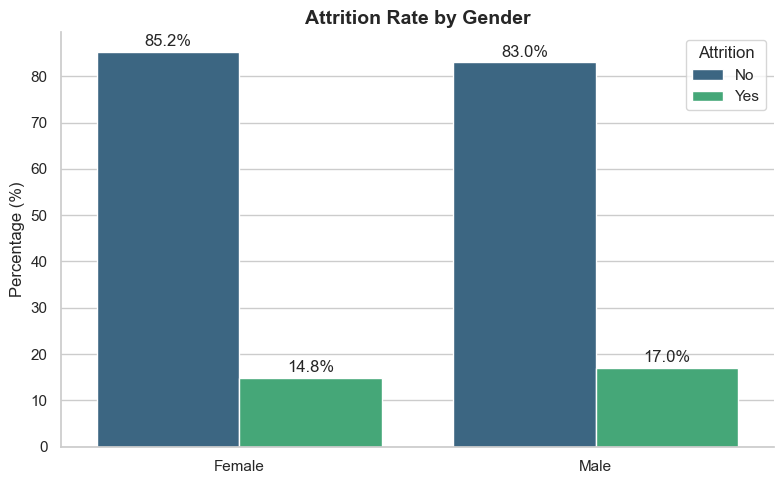

In [6]:
# Tasa de Attrition según Género

viz = Visualizaciones(
    dataframe=df_hr,
    palette_attrition=palette_attrition,
    palette_seq=palette_seq)

viz.tasa_attrition_hue(
    columna="Gender",
    hue="Attrition",
    titulo="Attrition Rate by Gender",
    xlabel="",
    ylabel="Percentage (%)",
    figsize=(8, 5),
    hue_order=["No", "Yes"])

### Interpretación - Análisis por género

El análisis por género muestra que el attrition es ligeramente superior en **Male** que en **Female**. Aunque en ambos grupos la mayoría de empleados permanece en la empresa, la proporción de bajas es algo mayor entre los hombres, lo que sugiere una diferencia, pero no una brecha especialmente marcada.

Por tanto, el género no parece actuar como uno de los factores más determinantes del attrition en comparación con otras variables analizadas, como el nivel del puesto, el salario, las horas extra o la satisfacción laboral. Aun así, puede ser una variable complementaria interesante si más adelante se cruza con otras dimensiones como Job Role, Department o Job Level.

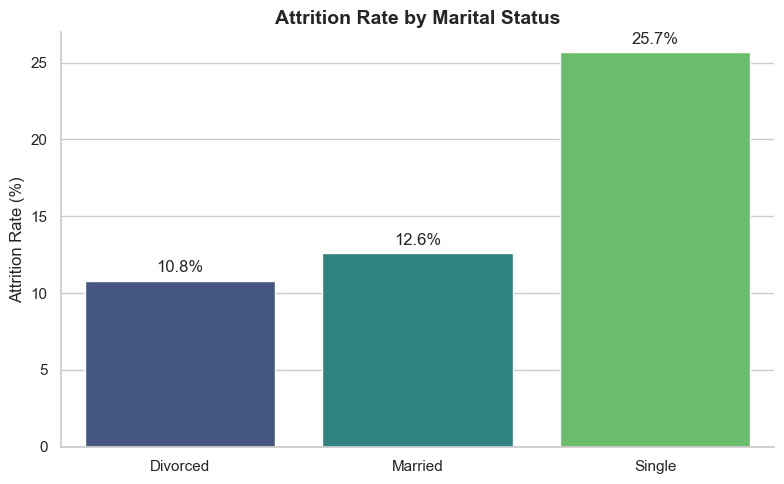

In [7]:
# Attrition Rate by Marital Status

viz.tasa_attrition_marital_status(xlabel="")

### Interpretación - Tasa de abandono según el estado civil

Se observa una diferencia clara en la tasa de abandono según el estado civil. Los empleados solteros presentan una tasa de attrition significativamente más alta (alrededor del 25%) en comparación con los empleados casados y divorciados, cuyos valores son notablemente inferiores.

Este resultado sugiere que los empleados solteros podrían tener una mayor predisposición a cambiar de empleo, posiblemente debido a una menor estabilidad personal o mayor flexibilidad para asumir nuevos retos laborales.

## 2. Estructura organizativa y distribución del attrition

En este bloque se analizan variables estructurales de la organización con el objetivo de identificar en qué perfiles, niveles jerárquicos y áreas de la empresa se concentra el attrition.

Se incluyen factores como el Job Level, el Job Role, el Department, el salario mensual y el Stock Option Level, ya que permiten comprender cómo se distribuye la rotación dentro de la estructura interna de la compañía.

El objetivo es detectar si existen colectivos o posiciones donde el attrition se concentra de forma desproporcionada y que, por tanto, requieran una atención prioritaria.

In [8]:
# Attrition según Job Level

pd.crosstab(df_hr["Job_Level"], df_hr["Attrition"], normalize="index").mul(100).round(2)

Attrition,No,Yes
Job_Level,,
1,73.66,26.34
2,90.26,9.74
3,85.32,14.68
4,95.28,4.72
5,92.75,7.25


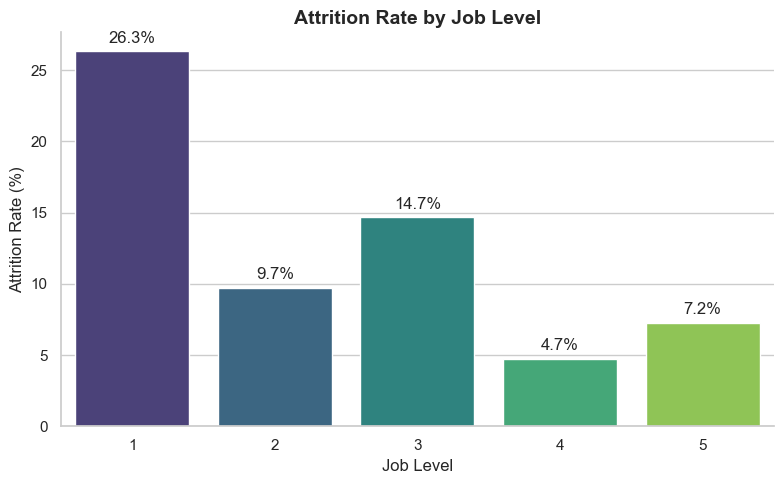

In [9]:
# Tasa de Attrition según Job Level

viz.tasa_attrition_categoria(
    columna="Job_Level",
    titulo="Attrition Rate by Job Level",
    xlabel="Job Level",
    ylabel="Attrition Rate (%)",
    figsize=(8, 5))

### Interpretación - Tasa de Attrition según Job Level

Se observa que el attrition se concentra principalmente en el Job Level 1, mientras que disminuye progresivamente en niveles superiores.

Este patrón sugiere que los empleados en posiciones más junior presentan una menor retención, lo que puede estar relacionado con menores oportunidades de desarrollo, condiciones salariales menos competitivas o una mayor rotación natural en las primeras etapas profesionales.

En términos organizativos, este resultado indica la necesidad de reforzar las estrategias de fidelización en los niveles iniciales, ya que representan el principal punto de fuga de talento dentro de la compañía.

In [10]:
# Distribución de Attrition por Job Role

attrition_jobrole = round(df_hr[df_hr['Attrition_num'] == 1]['Job_Role'].value_counts(normalize=True) * 100,2)

attrition_jobrole

Job_Role
Laboratory Technician             26.16
Sales Executive                   24.05
Research Scientist                19.83
Sales Representative              13.92
Human Resources                    5.06
Manufacturing Director             4.22
Healthcare Representative          3.80
Research & Development Manager     1.27
Research Director                  0.84
Sales Manager                      0.84
Name: proportion, dtype: float64

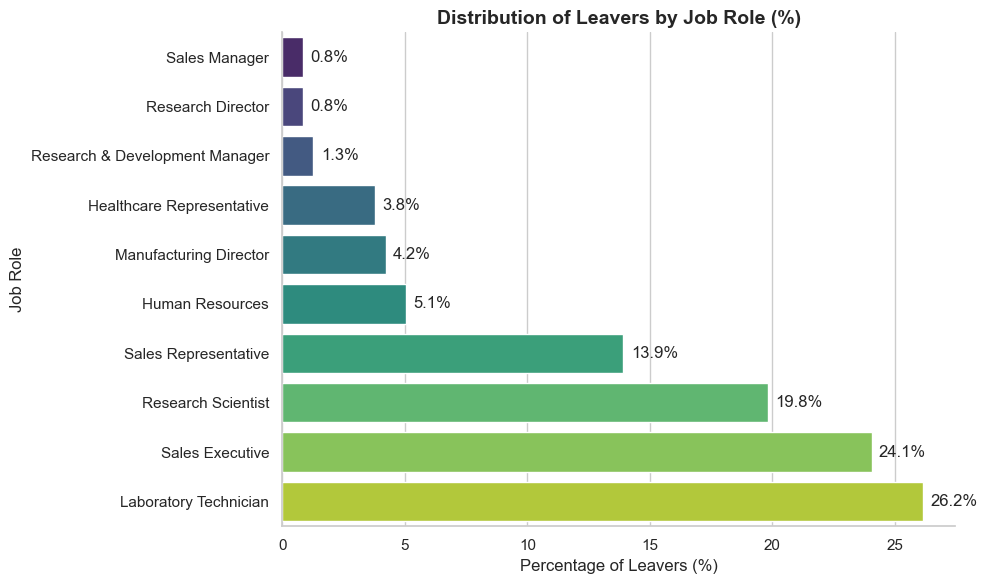

In [ ]:
# Visualización del peso de cada Job Role dentro del total de bajas

attrition_pct = (
    df_hr[df_hr["Attrition_num"] == 1]["Job_Role"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=attrition_pct.values,
    y=attrition_pct.index,
    palette=sns.color_palette(palette_seq, len(attrition_pct))
)

plt.title("Distribution of Leavers by Job Role (%)", fontsize=14, fontweight="bold")
plt.xlabel("Percentage of Leavers (%)")
plt.ylabel("Job Role")

for i, v in enumerate(attrition_pct.values):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center")

plt.tight_layout()
sns.despine()
plt.show()

### Interpretación - Job Role y Attrition

El análisis por Job Role muestra que ciertos puestos concentran un mayor peso dentro del total de bajas registradas.

Esto sugiere que el abandono no se distribuye de forma homogénea entre los distintos roles, sino que existen posiciones donde la salida de empleados es más frecuente en términos absolutos, posiblemente por su mayor volumen dentro de la plantilla o por características propias del puesto.

Por ello, esta visualización resulta útil para identificar qué roles aportan más bajas al conjunto de la organización, aunque sería necesario complementar este análisis con tasas relativas para valorar con mayor precisión el riesgo real de attrition en cada puesto.

In [13]:
# Distribución porcentual de Attrition por Department

round(df_hr[df_hr['Attrition_num'] == 1]['Department'].value_counts(normalize=True) * 100, 2)

Department
Research & Development    56.12
Sales                     38.82
Human Resources            5.06
Name: proportion, dtype: float64

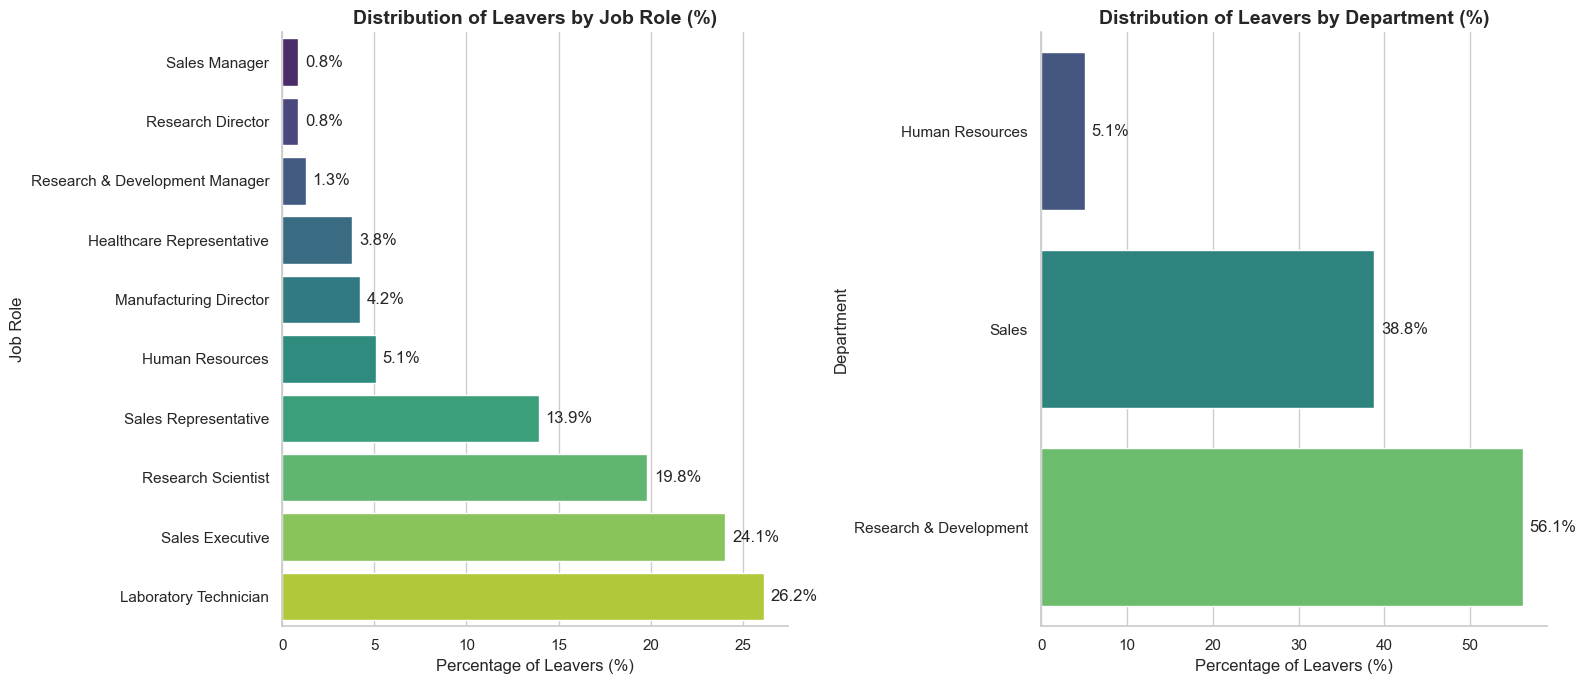

In [ ]:
# Attrition según Job Role y Department

viz.distribucion_bajas_doble(
    columna_1="Job_Role",
    columna_2="Department",
    attrition_col="Attrition_num",
    titulos=[
        "Distribution of Leavers by Job Role (%)",
        "Distribution of Leavers by Department (%)"
    ],
    figsize=(16, 7))

### Interpretación - Attrition y Department

Por departamento, las bajas se concentran principalmente en **Research & Development**, que acumula el **56.12%** del total, seguido de **Sales** con el **38.82%**. **Human Resources** apenas representa el **5.06%** de las salidas.

Este resultado indica que el volumen de bajas no se distribuye de forma uniforme entre departamentos, aunque esta concentración puede estar influida, en parte, por el tamaño relativo de cada área.

Por tanto, esta visualización permite identificar qué departamentos aportan más bajas en términos absolutos, pero conviene interpretar el resultado junto con el peso de cada departamento dentro de la plantilla.

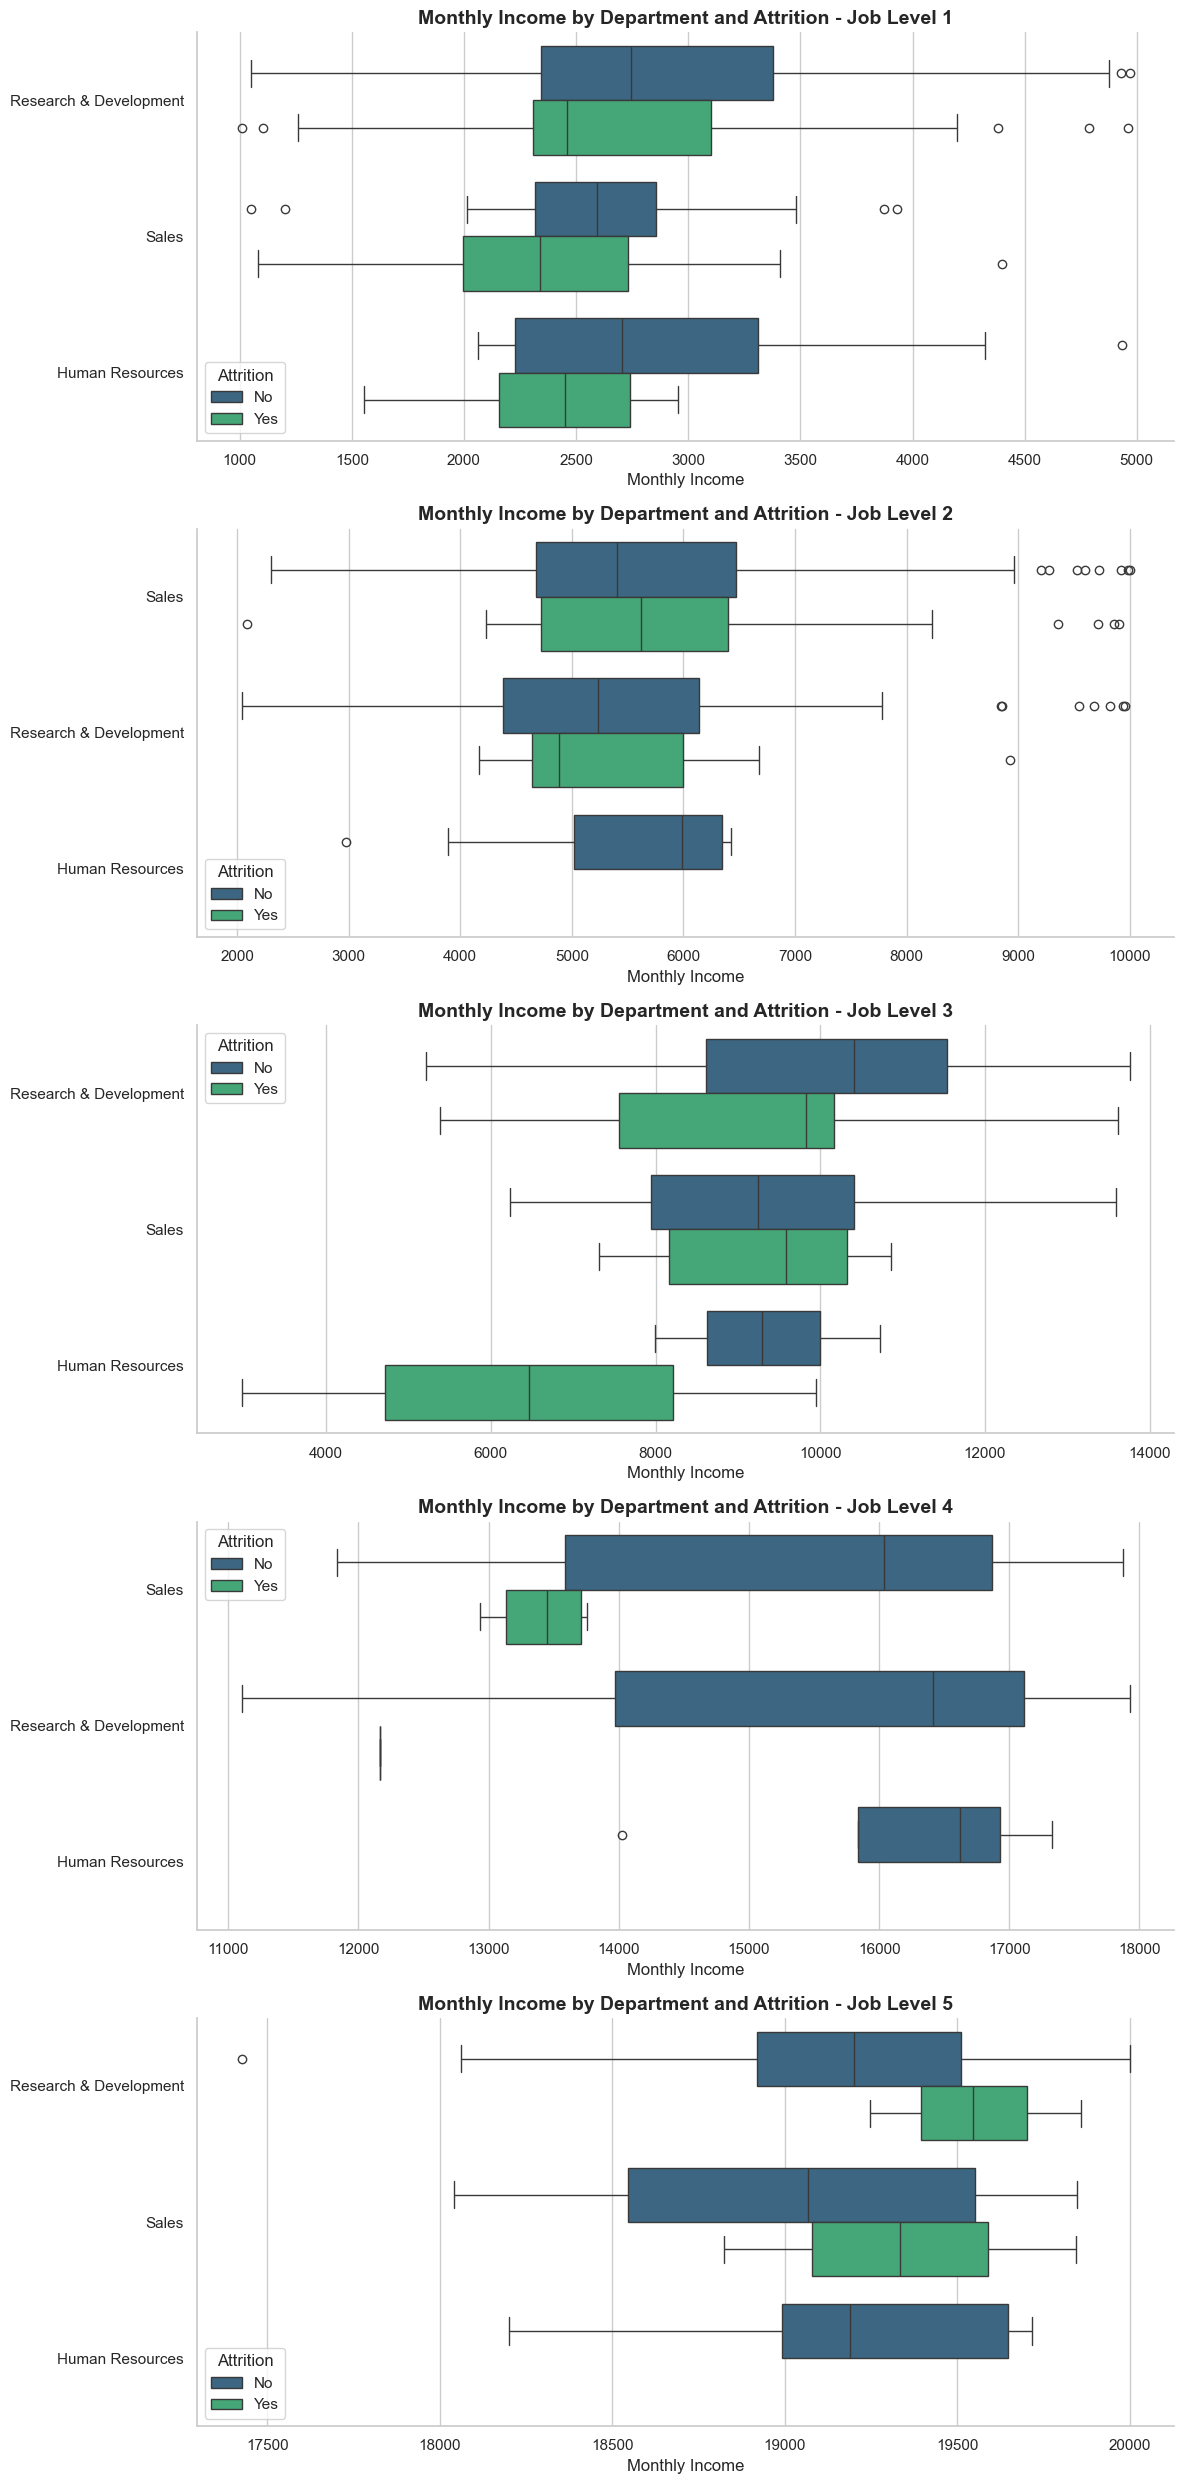

In [17]:
# Distribución de Monthly Income según Department, segmentando por Job Level y Attrition

viz.boxplot_income_department(
    income_col="Monthly_Income",
    department_col="Department",
    joblevel_col="Job_Level",
    attrition_col="Attrition",
    niveles=[1, 2, 3, 4, 5],
    hue_order=["No", "Yes"],
    figsize=(12, 25))

### Interpretación - Monthly Income segmentado por Department, Job Level y Attrition

La distribución salarial muestra diferencias claras según el departamento y, sobre todo, según el Job Level, confirmando que el salario mensual está estrechamente ligado a la posición ocupada dentro de la organización.

Además, se aprecia que las salidas tienden a concentrarse con mayor frecuencia en los tramos salariales más bajos, lo que sugiere que una menor retribución puede estar asociada a un mayor riesgo de abandono.

En conjunto, este resultado refuerza la idea de que la compensación económica es un factor relevante en la retención, especialmente en los niveles más iniciales de la estructura.

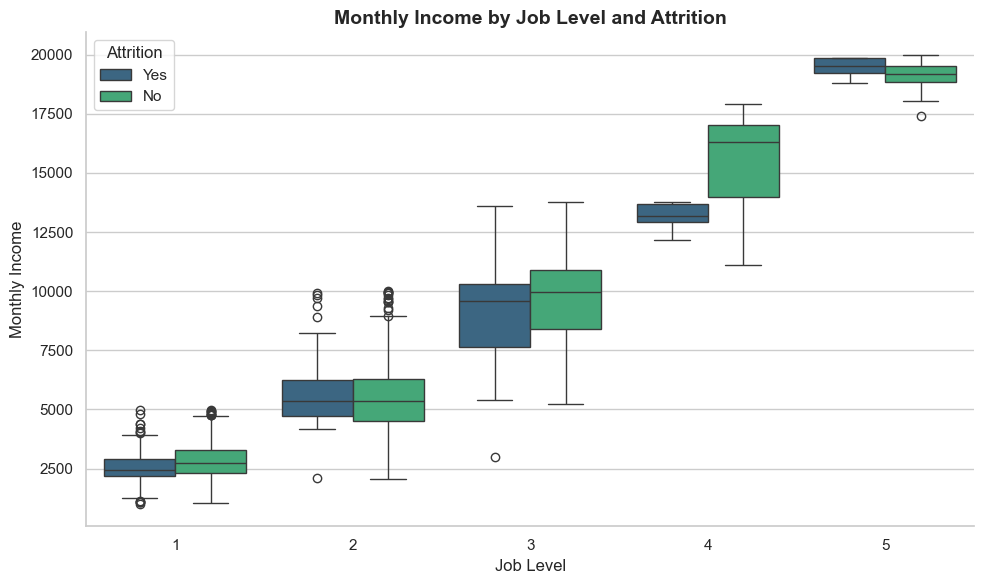

In [18]:
# Comparación de Monthly Income según Job Level y Attrition

viz.boxplot_income_joblevel(
    x="Job_Level",
    y="Monthly_Income",
    hue="Attrition",
    figsize=(10, 6))

### Interpretación - Comparación de Monthly Income según Job Level y Attrition

La visualización muestra que el salario mensual aumenta de forma progresiva a medida que crece el **Job Level**, lo que confirma una estructura salarial coherente con la jerarquía organizativa.

Al mismo tiempo, se observa que las salidas tienden a concentrarse con mayor frecuencia en los niveles salariales más bajos dentro de cada nivel, lo que sugiere que la compensación económica puede desempeñar un papel relevante en la permanencia.

Este patrón refuerza la idea de que los niveles iniciales no solo concentran más attrition, sino que además se asocian a paquetes retributivos menos competitivos.

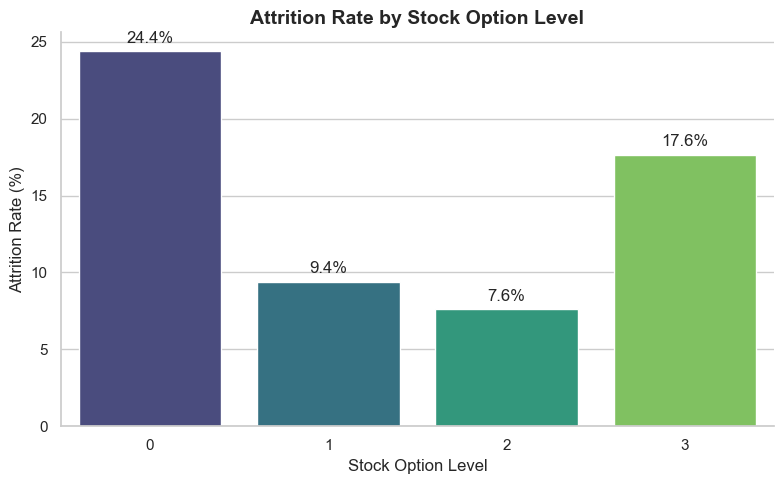

In [19]:
# Attrition Rate by Stock Option Level

viz.tasa_attrition_stock_option_level()

### Interpretación - Attrition y Acciones de la Empresa

La relación entre el nivel de stock options y el attrition muestra una tendencia general decreciente en los niveles intermedios: los empleados con niveles 1 y 2 presentan menores tasas de abandono en comparación con aquellos sin stock options (nivel 0), que registran la mayor tasa.

Esto sugiere que los incentivos a largo plazo pueden desempeñar un papel relevante en la retención, ya que refuerzan el vínculo del empleado con la empresa y mejoran la propuesta de valor ofrecida por la organización.

El repunte observado en el nivel 3 indica que esta relación no es completamente lineal, por lo que el attrition en los perfiles con mayor nivel de stock options probablemente esté influido también por otros factores adicionales.

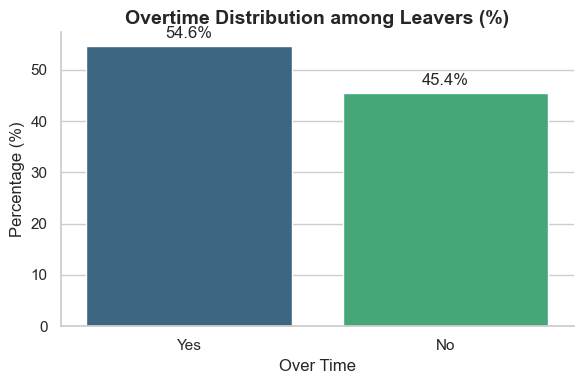

In [20]:
# Distribución de Over Time entre los empleados que abandonan la empresa

viz.overtime_bajas(
    overtime_col="Over_Time",
    attrition_col="Attrition_num",
    figsize=(6, 4))

### Interpretación - Horas extra trabajadas entre los que abandonan la empresa

La distribución muestra que una proporción elevada de los empleados que abandonan la empresa realizaba horas extra.

Este resultado sugiere que el overtime está presente con frecuencia entre los perfiles que causan baja, lo que apunta a una posible relación entre una mayor carga laboral y la salida de empleados.

No obstante, para confirmar el peso real de este factor conviene interpretarlo junto con análisis comparativos entre quienes realizan horas extra y quienes no.

## 3. Condiciones laborales y factores de riesgo del attrition

En este bloque se analizan variables relacionadas con la experiencia laboral del empleado, con el objetivo de evaluar si determinadas condiciones de trabajo pueden estar actuando como factores de riesgo del attrition.

Se incluyen aspectos como la frecuencia de viajes, la distancia al lugar de trabajo, la antigüedad en la empresa, el equilibrio vida-trabajo y distintas combinaciones de variables que permiten detectar patrones más complejos.

El objetivo es comprender no solo quién abandona la empresa, sino también en qué condiciones trabaja y cómo estas pueden influir en su decisión de salida.

En conjunto, este bloque permite analizar hasta qué punto el attrition responde a una acumulación de condiciones laborales desfavorables más que a un único factor aislado.

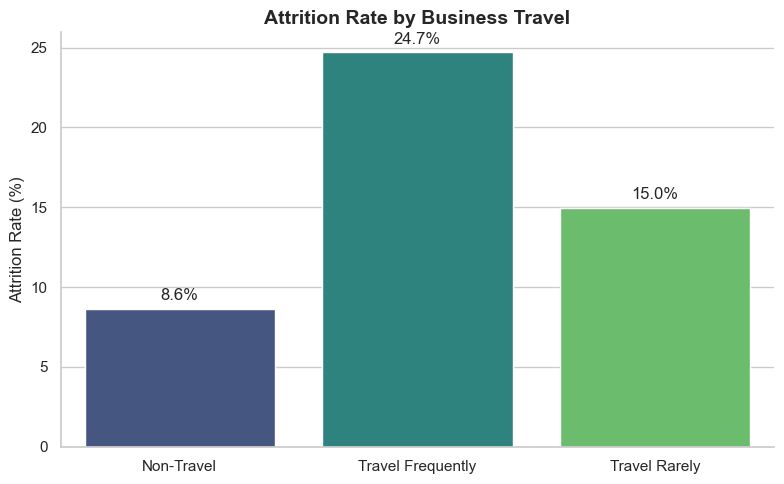

In [21]:
# Attrition Rate by Business Travel

viz.tasa_attrition_business_travel(excluir_valores=["Unknown"], xlabel="")

### Interpretación - Viajes de negocio y Attrition

El análisis revela una relación clara entre la frecuencia de viajes y el abandono. Los empleados que viajan con frecuencia presentan la tasa de attrition más elevada, seguidos por aquellos que viajan ocasionalmente, mientras que los empleados que no viajan muestran la tasa más baja.

Este patrón sugiere que la movilidad frecuente puede actuar como un factor de desgaste, afectando a la conciliación, la estabilidad y, en consecuencia, a la permanencia del empleado en la organización.

Lo relevante aquí es que el Business Travel no solo describe una característica del puesto, sino una condición de trabajo que puede incrementar el riesgo de salida cuando se combina con otras exigencias laborales.

In [22]:
# Distance From Home media según Attrition

df_attrition_distance = (df_hr.groupby('Attrition')['Distance_From_Home'].mean().reset_index().round(2))

df_attrition_distance

,Attrition,Distance_From_Home
0,No,8.92
1,Yes,10.63


### Interpretación - Distancia al lugar de trabajo y Attrition

El análisis muestra que la distancia al lugar de trabajo presenta cierta relación con el attrition, siendo algo mayor entre los empleados que abandonan la empresa.

Esto sugiere que los factores logísticos pueden influir en la permanencia, aunque probablemente no actúan como causa principal de forma aislada.

En este sentido, la distancia parece comportarse más como un factor complementario, capaz de aumentar el riesgo de attrition cuando se combina con otras condiciones menos favorables.

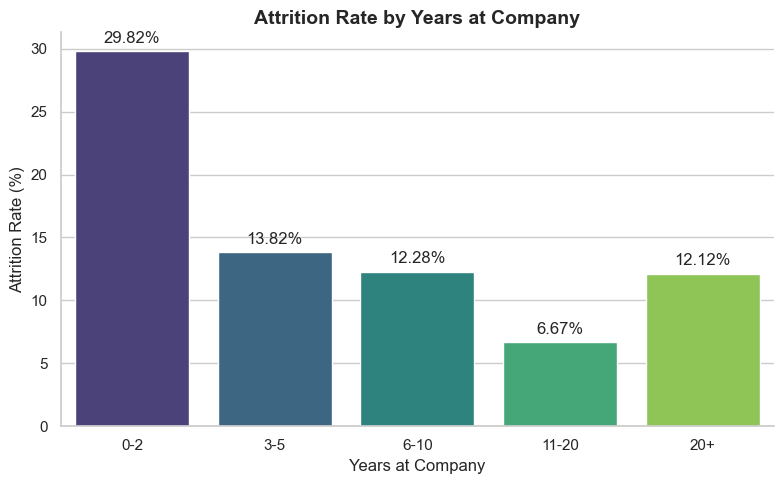

In [23]:
# Agrupación de Years_At_Company en tramos para una lectura más clara

viz.tasa_attrition_years_at_company_group(
    bins=[-1, 2, 5, 10, 20, 40],
    labels=["0-2", "3-5", "6-10", "11-20", "20+"])

### Interpretación - Antigüedad y Attrition

El attrition se concentra principalmente en los primeros años dentro de la empresa, disminuyendo a medida que aumenta la antigüedad.

Este patrón sugiere que existe una mayor rotación en las etapas iniciales del ciclo de vida del empleado, posiblemente asociada a procesos de adaptación, expectativas no cumplidas o búsqueda de mejores oportunidades externas.

Este resultado refuerza la importancia de los primeros años como periodo crítico para la retención, donde las acciones de onboarding, desarrollo y seguimiento pueden tener un impacto significativo en la permanencia.

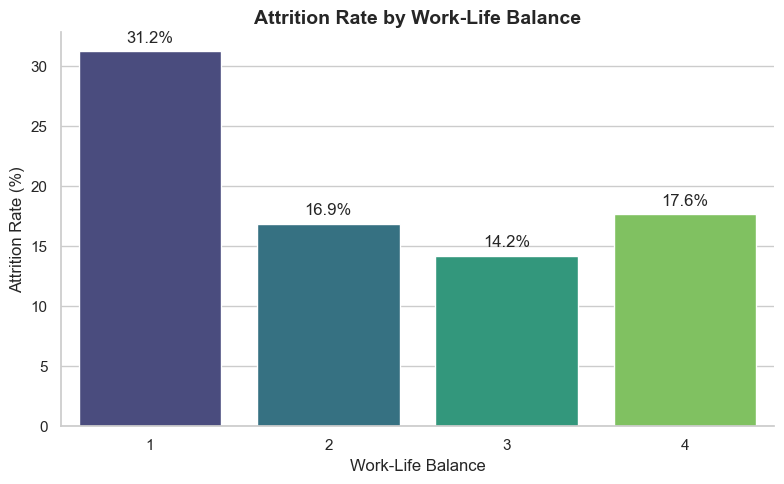

In [24]:
# Tasa de Attrition según cada nivel de Work-Life Balance

viz.tasa_attrition_categoria(
    columna="Work_Life_Balance",
    titulo="Attrition Rate by Work-Life Balance",
    xlabel="Work-Life Balance",
    ylabel="Attrition Rate (%)",
    figsize=(8, 5))

### Interpretación - Attrition y conciliación

Se observa que los niveles más bajos de Work-Life Balance están asociados a mayores tasas de attrition.

Este resultado sugiere que el equilibrio entre la vida personal y laboral es un factor determinante en la decisión de abandonar la empresa, especialmente cuando el empleado percibe una carga laboral excesiva o una falta de conciliación.

Desde una perspectiva organizativa, este hallazgo refuerza la necesidad de implementar políticas que favorezcan el equilibrio laboral, ya que su deterioro puede traducirse directamente en una mayor fuga de talento.

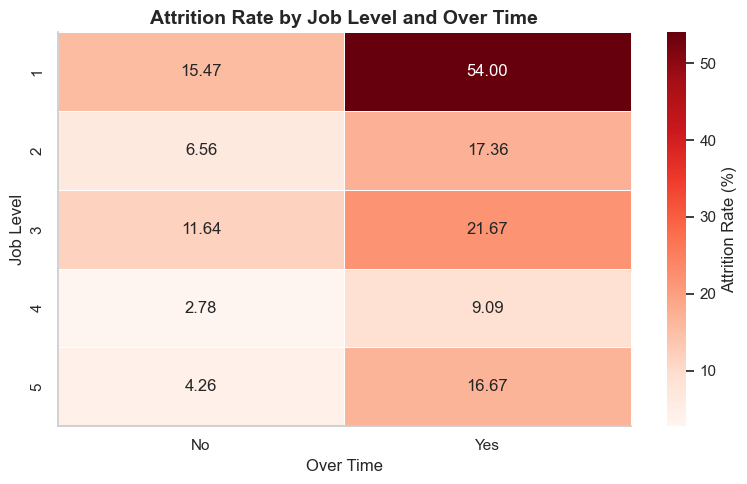

In [ ]:
# Attrition según Job Level y Over Time

viz.heatmap_attrition(
    fila="Job_Level",
    columna="Over_Time",
    attrition_col="Attrition_num",
    excluir_valores_columna="Unknown",
    ordenar_columnas=["No", "Yes"],
    titulo="Attrition Rate by Job Level and Over Time",
    figsize=(8, 5),
    cmap="Reds")

### Interpretación - Attrition según Job Level y Over Time

El análisis conjunto de **Job Level** y **OverTime** permite identificar un patrón muy claro: el attrition aumenta en todos los niveles jerárquicos cuando existe realización de horas extra, aunque el efecto es especialmente intenso en los niveles más bajos.

En particular, los empleados de **Job Level 1** que realizan **OverTime** concentran las tasas más elevadas de abandono, lo que sugiere que la combinación de una posición más junior con una mayor carga laboral constituye uno de los principales focos de riesgo dentro de la organización.

Este resultado refuerza la idea de que el attrition no depende únicamente del nivel jerárquico o del exceso de trabajo por separado, sino de la interacción entre ambos factores.

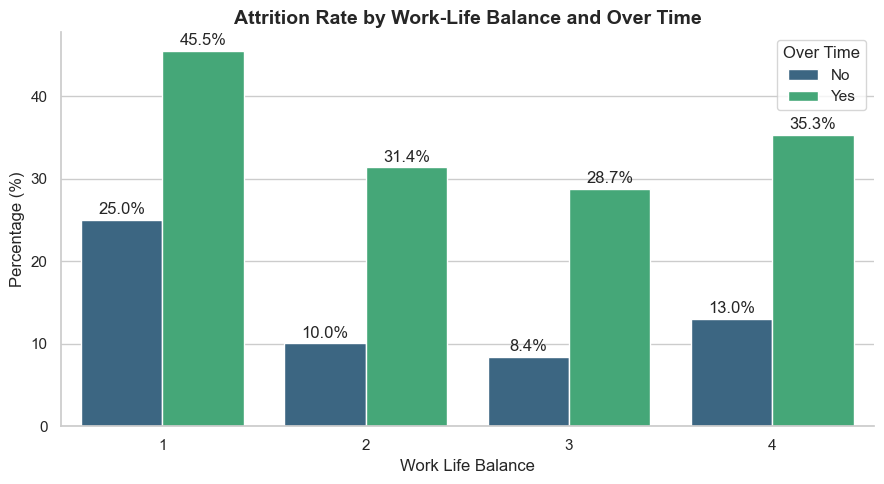

In [27]:
# Relación entre Work Life Balance y Over Time

viz.barras_attrition(
    x="Work_Life_Balance",
    hue="Over_Time",
    attrition_col="Attrition_num",
    excluir_valores_hue="Unknown",
    hue_order=["No", "Yes"],
    titulo="Attrition Rate by Work-Life Balance and Over Time",
    figsize=(9, 5))

### Interpretación - Conciliación y Horas Extra

El attrition aumenta de forma significativa cuando los empleados realizan **OverTime** en todos los niveles de **Work-Life Balance**, siendo especialmente elevado en los niveles más bajos de conciliación.

A medida que mejora el equilibrio vida-trabajo, la tasa de attrition disminuye en general. Sin embargo, incluso en los niveles más favorables, sigue siendo más alta entre quienes realizan horas extra.

Esto refuerza la idea de que el **OverTime** no solo actúa como factor de riesgo por sí mismo, sino que además intensifica el efecto negativo de una mala conciliación.

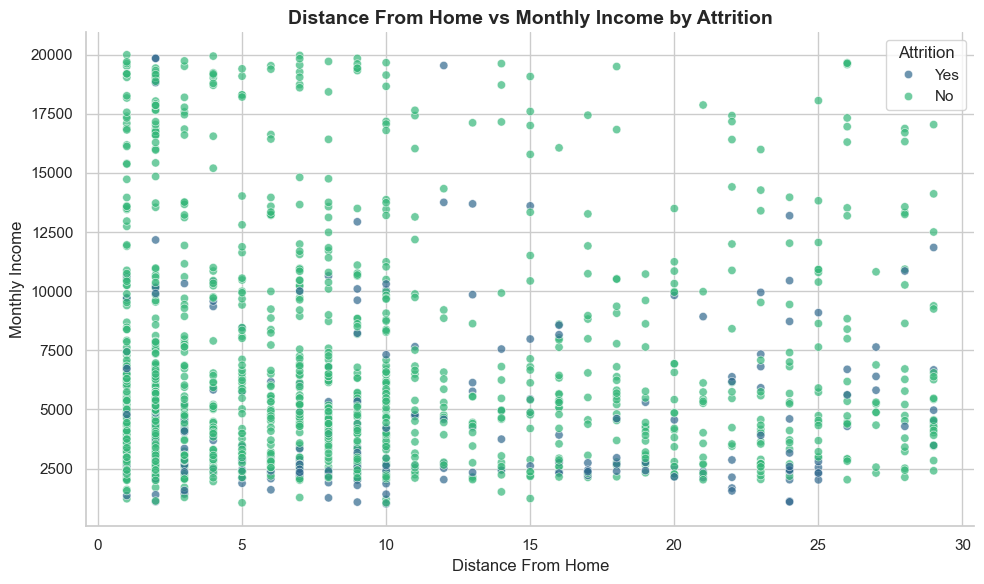

In [28]:
# Relación entre Distance From Home y Monthly Income según Attrition

viz.scatter_attrition(
    x="Distance_From_Home",
    y="Monthly_Income",
    hue="Attrition",
    titulo="Distance From Home vs Monthly Income by Attrition",
    figsize=(10, 6),
    alpha=0.7)

### Interpretación - Distancia al lugar de trabajo, salario y attrition

La relación entre **Distance From Home** y **Monthly Income** no muestra un patrón claramente diferenciado en función del attrition. La nube de puntos aparece bastante dispersa, sin una concentración evidente de bajas en rangos concretos de distancia o salario.

Esto sugiere que ninguna de estas dos variables, considerada de forma conjunta y aislada, permite explicar por sí sola la salida de empleados.

Por tanto, el attrition parece responder más a una combinación de factores que a una relación directa entre nivel salarial, distancia al trabajo y abandono.

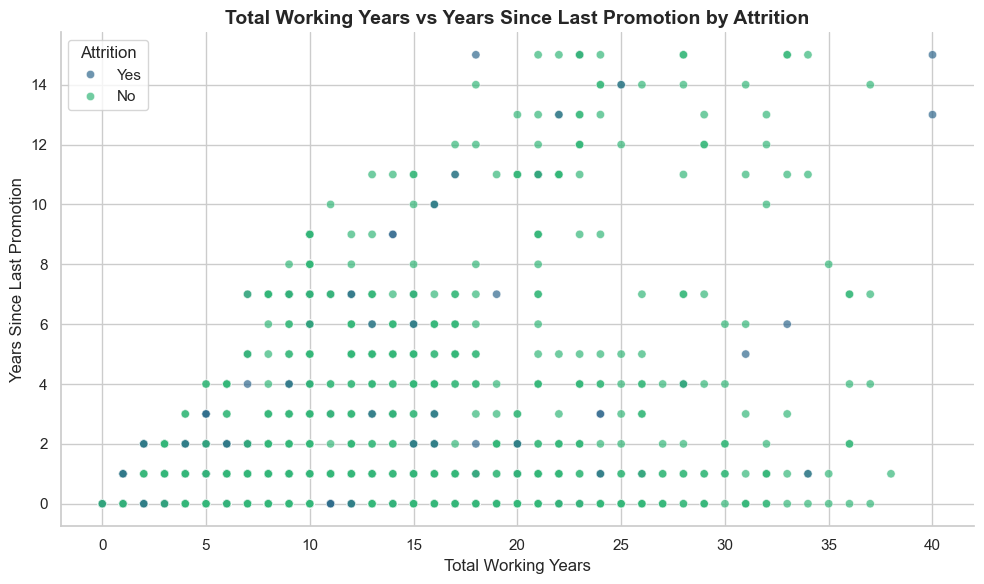

In [29]:
# Relación entre Total Working Years y Years Since Last Promotion, según Attrition

viz.scatter_attrition(
    x="Total_Working_Years",
    y="Years_Since_Last_Promotion",
    hue="Attrition",
    titulo="Total Working Years vs Years Since Last Promotion by Attrition",
    figsize=(10, 6),
    alpha=0.7)

### Interpretación - Antiguedad, tiempo sin promoción y attrition

La relación entre **Total Working Years** y **Years Since Last Promotion** muestra una tendencia creciente: a mayor trayectoria profesional, mayor probabilidad de acumular más años sin promoción, algo coherente desde el punto de vista temporal.

Sin embargo, no se aprecia una separación visual especialmente nítida entre empleados que abandonan la empresa y quienes permanecen, lo que sugiere que esta relación, por sí sola, no explica de forma clara el attrition.

En consecuencia, la falta de promoción podría influir en la salida de empleados en determinados casos, pero parece actuar más como un factor complementario que como un driver único del abandono.

## 4. Satisfacción del empleado como driver del attrition

Tras analizar los factores estructurales y las condiciones laborales, en este bloque se profundiza en el papel de la satisfacción del empleado como posible driver del attrition.

Se analizan distintas dimensiones de satisfacción para evaluar si existe una relación clara entre el nivel de satisfacción y la decisión de abandonar la empresa.

Este análisis permite complementar la visión más objetiva del puesto con una perspectiva subjetiva, centrada en cómo percibe el empleado su experiencia dentro de la organización.

In [30]:
# Comparación general de satisfacción entre quienes se van de la empresa y quienes permanecen

df_attrition_satisfaccion = round(
    df_hr.groupby("Attrition").agg(
        environment_satisfaction_mean=("Environment_Satisfaction", "mean"),
        job_involvement_mean=("Job_Involvement", "mean"),
        job_satisfaction_mean=("Job_Satisfaction", "mean"),
        relationship_satisfaction_mean=("Relationship_Satisfaction", "mean")).reset_index(), 2)

df_attrition_satisfaccion

,Attrition,environment_satisfaction_mean,job_involvement_mean,job_satisfaction_mean,relationship_satisfaction_mean
0,No,2.77,2.77,2.81,2.73
1,Yes,2.46,2.52,2.51,2.60


In [31]:
# Satisfacción media por Attrition y Department.

df_attrition_satisfaccion2 = round(
    df_hr.groupby(['Attrition', 'Department']).agg(
        environment_satisfaction_mean=("Environment_Satisfaction", "mean"),
        job_involvement_mean=("Job_Involvement", "mean"),
        job_satisfaction_mean=("Job_Satisfaction", "mean"),
        relationship_satisfaction_mean=("Relationship_Satisfaction", "mean")).reset_index(), 2)

df_attrition_satisfaccion2

,Attrition,Department,environment_satisfaction_mean,job_involvement_mean,job_satisfaction_mean,relationship_satisfaction_mean
0,No,Human Resources,2.76,2.80,2.71,2.84
1,No,Research & Development,2.79,2.77,2.80,2.74
2,No,Sales,2.73,2.76,2.83,2.71
3,Yes,Human Resources,2.33,2.50,2.42,3.08
4,Yes,Research & Development,2.47,2.56,2.50,2.52
5,Yes,Sales,2.47,2.47,2.53,2.65


### Interpretación - Satisfacción y Attrition por departamento

El patrón general de menor satisfacción entre quienes abandonan la empresa se mantiene en los tres departamentos, aunque no con la misma intensidad ni en las mismas dimensiones.

En **Research & Development** y **Sales**, las salidas se asocian a descensos bastante consistentes en ambiente, implicación, satisfacción con el puesto y relaciones. En **Human Resources**, en cambio, destacan especialmente **Environment Satisfaction** y **Job Satisfaction**, mientras que **Relationship Satisfaction** se mantiene en niveles similares o incluso algo superiores.

Esto sugiere que el attrition no responde exactamente al mismo tipo de malestar en todas las áreas, sino que puede estar impulsado por experiencias laborales diferentes según el departamento.

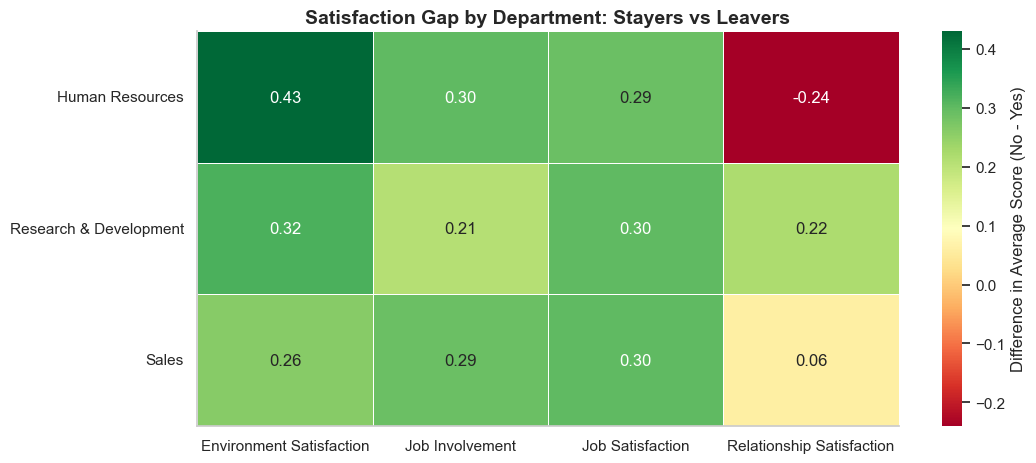

In [32]:
# Diferencia entre las medias de satisfacción de empleados que abandonan la empresa y empleados que permanecen en ella

columnas_satisfaccion = [
    "Environment_Satisfaction",
    "Job_Involvement",
    "Job_Satisfaction",
    "Relationship_Satisfaction"]

viz.heatmap_satisfaccion_departamento(
    columnas_satisfaccion=columnas_satisfaccion,
    attrition_col="Attrition",
    department_col="Department",
    figsize=(11, 4.8),
    cmap="RdYlGn")

### Interpretación -  Attrition y variables de satisfacción del empleado

El análisis de diferencias muestra que, en la mayoría de los casos, los empleados que abandonan la empresa presentan niveles de satisfacción inferiores a los de quienes permanecen, especialmente en **Environment Satisfaction**, **Job Involvement** y **Job Satisfaction**.

Las mayores caídas se observan en **Human Resources**, donde destacan descensos relevantes en **Environment Satisfaction** y **Job Satisfaction**. En **Research & Development**, las diferencias son consistentes en todas las dimensiones, lo que apunta a un desgaste más generalizado de la experiencia del empleado. En **Sales**, aunque las diferencias son algo más moderadas, también se aprecia una disminución clara en satisfacción e implicación.

En contraste, **Relationship Satisfaction** presenta un comportamiento distinto según el departamento. En **Human Resources** y **Sales**, los empleados que abandonan la empresa muestran niveles similares o incluso superiores en esta dimensión, mientras que en **Research & Development** sí sugiere una ligera caída. Esto apunta a que, en algunos casos, la decisión de abandonar la empresa podría no estar vinculada a las relaciones interpersonales, sino a otros factores como el entorno laboral, el contenido del puesto o la implicación en el trabajo.

En conjunto, los resultados indican que el attrition está asociado principalmente a una peor percepción del trabajo y del entorno laboral, más que a un problema generalizado en las relaciones dentro de la organización.

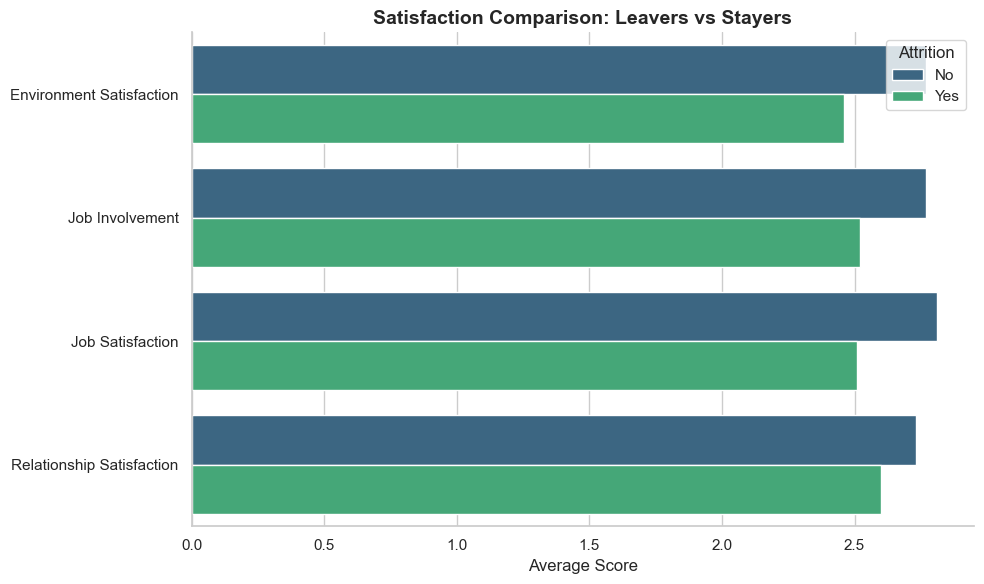

In [33]:
# Comparativa global de satisfacción entre las personas que abandonan la compañía y las que permanecen

viz.comparativa_satisfaccion(
    columnas_satisfaccion=columnas_satisfaccion,
    attrition_col="Attrition",
    figsize=(10, 6))

### Interpretación - Satisfacción global y Attrition

La comparativa global muestra que los empleados que abandonan la empresa presentan peores puntuaciones en las cuatro dimensiones analizadas. Las diferencias más marcadas aparecen en **Environment Satisfaction** y **Job Satisfaction**, lo que sugiere que tanto el entorno de trabajo como la satisfacción con el propio puesto están especialmente vinculados al attrition.

También se observan diferencias en **Job Involvement** y **Relationship Satisfaction**, aunque algo menos intensas. En conjunto, los resultados apuntan a que la salida de empleados no parece explicarse por un único factor aislado, sino por una experiencia laboral globalmente menos positiva entre quienes terminan abandonando la organización.

## Conclusiones

El análisis realizado muestra que el attrition en **ABC Corporation** no es aleatorio, sino que responde a patrones claros asociados a distintos factores.

En primer lugar, el abandono se concentra en perfiles más jóvenes, con menor antigüedad y menor nivel salarial, lo que sugiere dificultades en la retención del talento en etapas iniciales.

A nivel organizacional, los niveles más bajos (Job Level 1) y determinados roles operativos concentran la mayor parte de las salidas, lo que indica menores oportunidades de desarrollo y condiciones menos competitivas.

En cuanto a las condiciones laborales, factores como el overtime y un peor equilibrio vida-trabajo muestran una relación directa con el attrition, lo que refuerza la importancia del entorno laboral en la decisión de abandono.

Por último, la satisfacción del empleado aparece como un factor clave, evidenciando que una menor satisfacción se asocia claramente con mayores tasas de salida.

En conjunto, el attrition parece responder a una combinación de factores estructurales, condiciones laborales exigentes y una menor satisfacción del empleado, lo que pone de manifiesto la necesidad de abordarlo desde una perspectiva estratégica e integral.

## Recomendaciones

A partir de los resultados obtenidos, se proponen las siguientes líneas de actuación, priorizadas según su impacto y facilidad de implementación:

- **Control del overtime (corto plazo)**  
  Implementar medidas para limitar las horas extra y mejorar la planificación del trabajo. El exceso de carga laboral se ha identificado como uno de los factores más directamente relacionados con el attrition.

- **Mejora del Work-Life Balance (corto-medio plazo)**  
  Fomentar políticas que favorezcan el equilibrio entre vida personal y laboral, especialmente en aquellos perfiles más expuestos a condiciones de trabajo exigentes.

- **Refuerzo de la retención en perfiles junior (medio plazo)**  
  Diseñar planes de desarrollo profesional, acompañamiento y revisiones salariales en las primeras etapas del empleado, donde se concentra una mayor rotación.

- **Revisión de condiciones en Job Level 1 (medio plazo)**  
  Analizar en detalle las condiciones laborales, expectativas y oportunidades de crecimiento en los niveles más bajos, ya que representan el principal punto de fuga de talento.

- **Seguimiento de la satisfacción del empleado (largo plazo)**  
  Establecer mecanismos periódicos de medición de la satisfacción (encuestas, feedback continuo) y planes de acción asociados, con especial foco en los colectivos con mayor riesgo de abandono.

En conjunto, estas acciones permitirían abordar el attrition de forma integral, actuando tanto sobre factores inmediatos como sobre elementos estructurales y culturales de la organización.